# 1. Carga y preprocesado

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (matthews_corrcoef, average_precision_score, roc_auc_score,
                             precision_score, recall_score, f1_score, precision_recall_curve)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.simplefilter("ignore", FutureWarning)
import utils
from config import SEED, MIN_CONSECUTIVE_DAYS as M_C
import time
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D,
                                     AveragePooling1D, Dense, GlobalMaxPooling1D)
from tensorflow.keras.layers import SpatialDropout1D, Concatenate, Dropout, Lambda, Softmax
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

tf.random.set_seed(SEED)
np.random.seed(SEED)

Se carga el *dataset* de las series crudas de consumo obteniendo el mismo conjunto empleado en enfoque tabular: *max_gap670* y al menos 60 días consecutivos. Realizando una limpieza que incluye: la corrección de registros erróneos (`interpolate_spikes`) y la imputación mediante interpolación lineal —justificada en el *EDA*— de ≤7 nulos internos.

In [ ]:
def preprocess_raw_dataset(path, n=M_C, max_gap=670):
    df = pd.read_csv(path)
    df = (df
        .pipe(utils.drop_industrial_client)
        .pipe(utils.drop_clientID)                                  # Elimina la columna 'CONS_NO' (Consumer Number)
        .pipe(utils.drop_duplicated_rows)                           # Elimina filas duplicadas
        .pipe(utils.drop_inactive_clients)                          # Elimina clientes inactivos: solo 0s y/o nulos
        .pipe(utils.drop_n_not_consecutive_values, n=n)             # Elimina clientes sin al menos 60 valores no nulos consecutivos
        .pipe(utils.drop_large_max_gaps, max_gap_threshold=max_gap) # Elimina clientes con gaps internos enormes
        .pipe(utils.interpolate_spikes)                             # Reemplaza lecturas erróneas por nulos y los interpola
    )
    df = df.interpolate(method='linear', limit_direction='both', limit_area='inside', limit=7)

    return df

df_path = "data/dataset.csv"
df = preprocess_raw_dataset(df_path, n=M_C, max_gap=670)
print("Freq:", df['FLAG'].value_counts(normalize=True))
n_flag1, n_flag0 = df[df['FLAG']==1].shape[0], df[df['FLAG']==0].shape[0]
df.head(2)

Freq: FLAG
0    0.912428
1    0.087572
Name: proportion, dtype: float64


,1/1/2014,1/2/2014,1/3/2014,1/4/2014,1/5/2014,1/6/2014,1/7/2014,1/8/2014,1/9/2014,1/10/2014,...,10/23/2016,10/24/2016,10/25/2016,10/26/2016,10/27/2016,10/28/2016,10/29/2016,10/30/2016,10/31/2016,FLAG
0,0.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.83,0.02,0.06,0.58,0.89,0.35,0.38,0.70,0.25,1
1,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.91,17.13,14.32,16.37,26.33,19.06,17.38,13.94,14.14,1


Seguidamente, se aplica *clip* en los percentiles 0.01 y 0.99 para mitigar el impacto de los valores más extremos. Y se estandarizan las series, ignorando los valores nulos, tanto en la media como en la desviación típica, para no sesgar la distribución erróneamente.

Tal y como se indicó en el *EDA*, también se construye una máscara de nulos para que el modelo pueda aprender el más que demostrado (ver `01_EDA.ipynb` y `03_ML_modeling.ipynb`) carácter *MNAR* de los valores ausentes.

In [ ]:
def prepare_dl_data(df, random_seed=SEED):
    train_df, val_df, test_df = utils.stratified_train_val_test_split(df, random_state=random_seed)

    # Clip basado en train (obviando Y)
    cols = df.columns[:-1]
    lower = train_df[cols].quantile(0.01)
    upper = train_df[cols].quantile(0.99)
    train_df[cols] = train_df[cols].clip(lower=lower, upper=upper, axis=1)
    val_df[cols]   = val_df[cols].clip(lower=lower, upper=upper, axis=1)
    test_df[cols]  = test_df[cols].clip(lower=lower, upper=upper, axis=1)

    # Grupos de X e y
    X_train = train_df.drop(columns=['FLAG']).values
    y_train = train_df['FLAG'].values
    X_val = val_df.drop(columns=['FLAG']).values
    y_val = val_df['FLAG'].values
    X_test = test_df.drop(columns=['FLAG']).values
    y_test = test_df['FLAG'].values

    # Media y std para escalar ignorando NaNs (SOLO en train)
    mean = np.nanmean(X_train, axis=0)
    std = np.nanstd(X_train, axis=0)

    # ¿Todos los clientes con el mismo consumo?
    # Sería extraño, pero se evitan divisiones por 0
    std[std == 0] = 1.0

    # Escalado
    X_train_scaled = (X_train - mean) / std
    X_val_scaled   = (X_val - mean) / std
    X_test_scaled  = (X_test - mean) / std

    # Máscara de nulos para el modelo
    mask_train = (~np.isnan(X_train)).astype(float)
    mask_val   = (~np.isnan(X_val)).astype(float)
    mask_test  = (~np.isnan(X_test)).astype(float)

    # Reemplazo de NaNs por 0.0
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0)
    X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0)

    # Conjuntos finales
    X_train_dl = np.stack((X_train_scaled, mask_train), axis=-1)
    X_val_dl   = np.stack((X_val_scaled, mask_val), axis=-1)
    X_test_dl  = np.stack((X_test_scaled, mask_test), axis=-1)

    return X_train_dl, X_val_dl, X_test_dl, y_train, y_val, y_test

X_train_dl, X_val_dl, X_test_dl, y_train, y_val, y_test = prepare_dl_data(df, SEED)

# 2. Arquitectura *Deep Learning (DL)*

El objetivo de este bloque de *DL* es probar que las secuencias temporales crudas permiten alcanzar métricas predictivas similares o superiores al mejor modelo tabular. La dificultad de esta tarea radica en que, esta vez, el modelo no recibe variables filtradas que facilitan la detección de fraude, sino que debe ser el mismo modelo quién detecte y aprenda los patrones superando la gran cantidad de ruido ya identificada. Para ello, se propone una arquitectura basada en Redes Neuronales Convolucionales unidimensionales (*CNN 1D*) multiescala.

**Justificación de la propuesta inicial**

* Para incluir la información discriminativa *MNAR*, la red recibe un tensor de dos canales: la serie de consumo (escalada) y una máscara binaria de nulos.

* El análisis temporal demostró que los perfiles fraudulentos exhiben una mayor variabilidad a largo plazo, fuertes alteraciones en la estacionalidad anual —en especial en verano— y oscilaciones más violentas a corto plazo. Para capturar esta información, se ha implementado una arquitectura, con cuatro ramas convolucionales de diferentes tamaños de *kernel* (7, 31, 91 y 365 días).
    * Dada la longitud de las series y su carácter ruidoso, se probará la aplicación de `AveragePooling1D` (media de registros en una ventana) de 7. Buscando mitigar el ruido, la dificultad de aprendizaje y la eficiencia al reducir la señal unos 148 días en lugar de 1,034.

* El *EDA* mostró una gran variedad de perfiles de fraude, con patrones tanto persistentes como puntuales. Por ello, la red combina `GlobalAveragePooling1D` y `GlobalMaxPooling1D`: el primero resume la presencia global de los patrones aprendidos, mientras que el segundo conserva sus activaciones más intensas.

* Para mitigar el sobreajuste y forzar al modelo a aprender patrones diversificados, se valoran distintas medidas:
    * La regularización *L2* para penalizar pesos grandes.
    * *Dropout* para desactivar pesos al azar.
    * `SpatialDropout1D` para evitar filtros (*feature maps*) sesgados.

* De igual forma que en el enfoque tabular, se compila monitorizando la *PR-AUC* y se valorará el uso de pesos por clase.


In [ ]:
def build_multi_scale_cnn(input_shape, spatial_drop=0.2, dense_drop=0.5, l2_reg=None, downsample7=False):
    inputs = Input(shape=input_shape)
    x_in = inputs

    if not downsample7:
        kernel_sizes = [7, 31, 91, 365]
    # Variante downsampling
    else:
        kernel_sizes = [1, 4, 13, 52]  # 7*1=semanal, 7*4≈mensual, etc
        x_in = AveragePooling1D(pool_size=7)(x_in)

    # Regularización
    reg = l2(l2_reg) if l2_reg else None

    # Escala semanal, mensual, trimestral y anual
    branches = []
    for k in kernel_sizes:
        b = Conv1D(32, k, padding='same', kernel_regularizer=reg)(x_in)
        b = BatchNormalization()(b)
        b = ReLU()(b)
        b = SpatialDropout1D(spatial_drop)(b)
        branches.append(b)

    # Concatenación
    x = Concatenate()(branches)

    # Segunda capa para mezclar las escalas (¿cómo interactúan?)
    x = Conv1D(filters=64, kernel_size=3, padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Pooling mixto
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    combined = Concatenate()([avg_pool, max_pool])

    # Clasificador final
    x = Dense(64, activation='relu', kernel_regularizer=reg)(combined)
    x = Dropout(dense_drop)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    return model

## 2.1. Experimentos: primera iteración

Inicialmente se valora:
1. Modelo base: *dropout* previo a la última capa de salida del 0.5 y un *SpatialDropout1D* de 0.2.
2. Modelo base con pesos por clase.
3. Modelo base que aumenta el *dropout* a 0.6, *SpatialDropout1D* a 0.3 e incluye regularización *L2*.
4. Modelo base con *downsampling*.

In [ ]:
def run_experiment(exp_name, X_tr, y_tr, X_v, y_v,
                   model_fn=build_multi_scale_cnn,
                   class_weight=None,
                   spatial_drop=0.2, dense_drop=0.5, l2_reg=None,
                   epochs=30, verbose=0,
                   downsample7=False):

    print(f"\n{'='*50}")
    print(f"-> {exp_name}")
    print(f"{'='*50}")

    # Input y modelo
    timesteps, channels = X_tr.shape[1], X_tr.shape[2]
    model = model_fn(
        input_shape=(timesteps, channels),
        spatial_drop=spatial_drop,
        dense_drop=dense_drop,
        l2_reg=l2_reg,
        downsample7=downsample7
    )

    # Callbacks con patience reducida
    early_stopping = EarlyStopping(monitor='val_pr_auc', patience=5, restore_best_weights=True, mode='max')
    reduce_lr = ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.5, patience=3, min_lr=1e-5)

    # Entreno
    history = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=128,
        validation_data=(X_v, y_v),
        class_weight=class_weight,
        callbacks=[early_stopping, reduce_lr],
        verbose=verbose
    )

    # Plots
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['pr_auc'], label='Train PR-AUC')
    plt.plot(history.history['val_pr_auc'], label='Val PR-AUC')
    plt.title('PR-AUC')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

    # Pred y métricas (sobre validación)
    val_probs = model.predict(X_v, verbose=0).ravel()
    val_pr_auc = average_precision_score(y_v, val_probs)
    val_roc_auc = roc_auc_score(y_v, val_probs)
    print("== VALIDATION RESULTS ==")
    print(f"Epochs: {len(history.history['loss'])} (restore_best_weights)")
    print(f"PR-AUC:  {val_pr_auc:.4f}")
    print(f"ROC-AUC: {val_roc_auc:.4f}")


-> Base Model


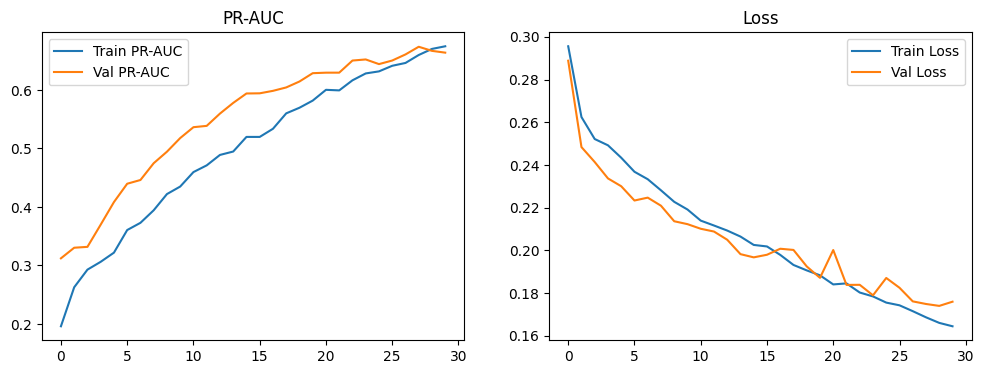

== VALIDATION RESULTS ==
Epochs: 30 (restore_best_weights)
PR-AUC:  0.6742
ROC-AUC: 0.9048


In [ ]:
run_experiment("Base Model", X_train_dl, y_train, X_val_dl, y_val)

Class weights: {0: 1.0, 1: np.float64(3.1262001627339298)}

-> Class Weights


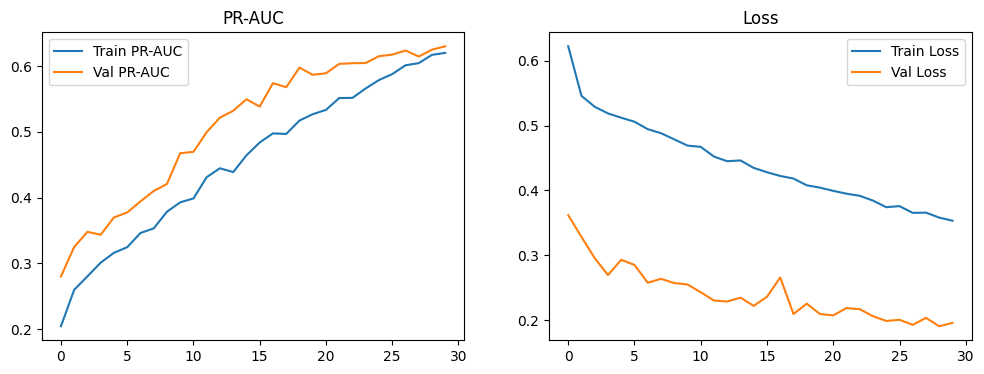

== VALIDATION RESULTS ==
Epochs: 30 (restore_best_weights)
PR-AUC:  0.6305
ROC-AUC: 0.8906


In [ ]:
neg, pos = np.bincount(y_train)
cw = {0: 1.0, 1: (neg / pos) * 0.3}
print("Class weights:", cw)

run_experiment("Class Weights",
                X_train_dl, y_train, X_val_dl, y_val,
                class_weight=cw)


-> Increase Dropout | Include L2


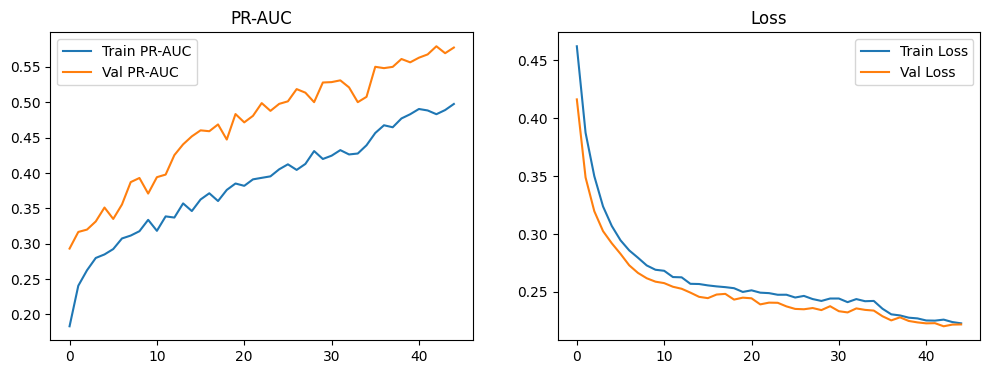

== VALIDATION RESULTS ==
Epochs: 45 (restore_best_weights)
PR-AUC:  0.5798
ROC-AUC: 0.8756


In [ ]:
run_experiment("Increase Dropout | Include L2",
                X_train_dl, y_train, X_val_dl, y_val,
                spatial_drop=0.3, dense_drop=0.6, l2_reg=1e-3,
                epochs=45)


-> Downsampling (7)


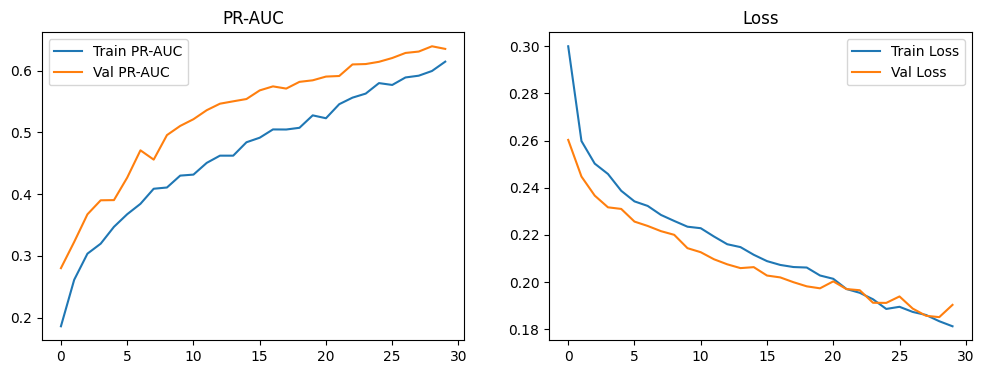

== VALIDATION RESULTS ==
Epochs: 30 (restore_best_weights)
PR-AUC:  0.6400
ROC-AUC: 0.8913


In [ ]:
run_experiment("Downsampling (7)",
               X_train_dl, y_train, X_val_dl, y_val,
               downsample7=True)

Viendo que:
* En ninguna variante se comete sobreajuste. En las últimas épocas la función de pérdida de validación se aplana y en algunos casos (sobre todo el modelo base) se vuelve irregular, aunque sin incrementar significativamente.
* El *downsampling* parece reducir levemente la capacidad de la red.
* El incremento del *dropout* y la inclusión de la regularización no tiene un impacto significativo (aumentar épocas para ver los mismos resultados), lo que, combinado con los gráficos, puede indicar que la red alcanza un límite discriminativo en validación alrededor de *PR-AUC = 0.67* y *ROC-AUC = 0.90*.
* Los pesos de clase no tienen un impacto notoriamente positivo, pero pueden valorarse.

Alternativamente, se propone experimentar con una variante del *dataset* más reducida pero con muestras más consistentes. Buscando responder a: ¿incluir solo registros estables aumenta la capacidad predictiva?

In [ ]:
len_og = len(df)
flag_og = df["FLAG"].value_counts()

# Carga del nuevo dataset
df2 = preprocess_raw_dataset(df_path, n=180, max_gap=200)
# Output: ¿cómo se reducen las muestras?
flag_new = df2["FLAG"].value_counts()
print("FLAG (new sizes):")
for clss in flag_og.index:
    og = flag_og.get(clss, 0)
    new = flag_new.get(clss, 0)
    pct_lost = (og - new) / og * 100 if og else 0
    print(f" Class {clss}: {og} -> {new} (-{pct_lost:.1f}%)")
len_new = len(df2)
print(f"\nNew length: {len_new} (-{(len_og - len_new) / len_og * 100:.1f}%)")
X_train_dl2, X_val_dl2, X_test_dl2, y_train2, y_val2, y_test2 = prepare_dl_data(df2, SEED)

FLAG (new sizes):
 Class 0: 36592 -> 31190 (-14.8%)
 Class 1: 3512 -> 2646 (-24.7%)

New length: 33836 (-15.6%)



-> Base Model | Reduced Dataset (more consistent samples)


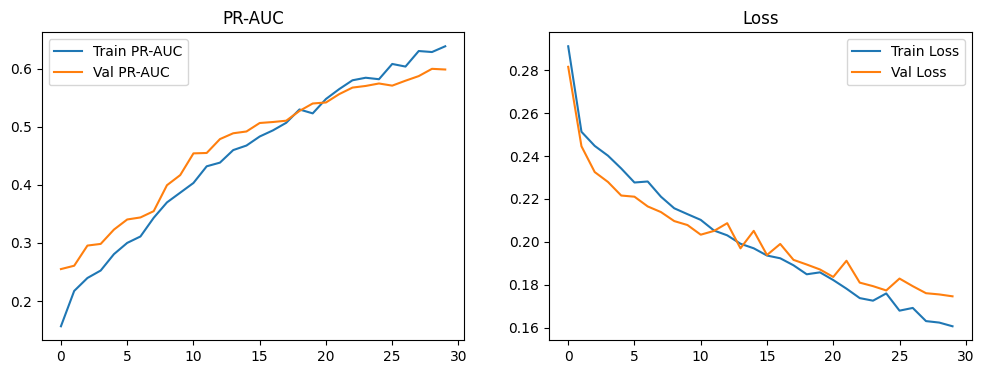

== VALIDATION RESULTS ==
Epochs: 30 (restore_best_weights)
PR-AUC:  0.6002
ROC-AUC: 0.8850


In [ ]:
run_experiment("Base Model | Reduced Dataset (more consistent samples)", X_train_dl2, y_train2, X_val_dl2, y_val2)

Con unos resultados bastante peores, no queda justificada la reducción de muestras, ya que a la par, empeora la utilidad del modelo. Por lo tanto, se sigue iterando sobre el conjunto inicial.

## 2.2. Experimentos: segunda iteración, atención temporal

Dados los requisitos éticos, legales y operativos en la detección de fraude eléctrico, la explicabilidad del modelo es un factor clave. Para mejorarla, se propone sustituir las capas de *pooling* por un mecanismo de atención temporal.

A diferencia del *pooling*, la atención evalúa la secuencia y asigna un peso de importancia (o probabilidad) a cada día (*timestep*). El resultado es una suma ponderada que resume el comportamiento del cliente, permitiendo reconocer en qué días se fijó la red para emitir la predicción.


-> Attention


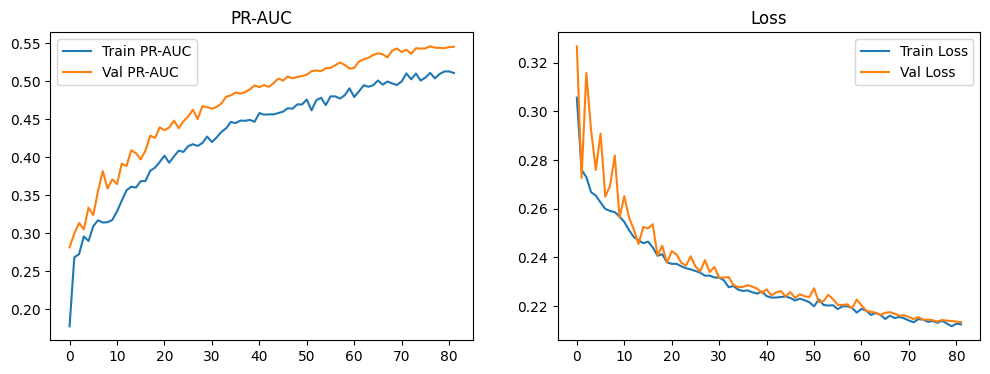

== VALIDATION RESULTS ==
Epochs: 82 (restore_best_weights)
PR-AUC:  0.5465
ROC-AUC: 0.8578


In [ ]:
def build_multi_scale_cnn_attention(input_shape, spatial_drop=0.2, dense_drop=0.5, l2_reg=None, downsample7=False):
    # Igual que el modelo base...
    inputs = Input(shape=input_shape)
    x_in = inputs

    if not downsample7:
        kernel_sizes = [7, 31, 91, 365]
    else:
        kernel_sizes = [1, 4, 13, 52]
        x_in = AveragePooling1D(pool_size=7)(x_in)

    reg = l2(l2_reg) if l2_reg else None

    branches = []
    for k in kernel_sizes:
        b = Conv1D(32, k, padding='same', kernel_regularizer=reg)(x_in)
        b = BatchNormalization()(b)
        b = ReLU()(b)
        b = SpatialDropout1D(spatial_drop)(b)
        branches.append(b)

    x = Concatenate()(branches)

    x = Conv1D(64, 3, padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Pero sustituyendo Pooling por attention: scores por timesteps, normalización y aplicación (suma ponderada)
    score = Dense(1, activation='tanh')(x)
    attention_weights = tf.keras.layers.Softmax(axis=1, name="attention_weights")(score)
    context = Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1))([x, attention_weights])

    # Clasificador final
    x = Dense(64, activation='relu', kernel_regularizer=reg)(context)
    x = Dropout(dense_drop)(x)
    outputs = Dense(1, activation='sigmoid', name="output")(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    return model

run_experiment("Attention",X_train_dl, y_train, X_val_dl, y_val,
                model_fn=build_multi_scale_cnn_attention,
                epochs=100, l2_reg=1e-4)

Tras saltar el *early stopping*, la *PR-AUC* ha caído drásticamente frente al modelo base. Al probar la ejecución con *downsampling* (no se muestra) las métricas se reducen aún más.

Al eliminar el `GlobalMaxPooling1D`, la red pierde la capacidad de conservar las activaciones más intensas de los patrones aprendidos. Esto puede ser relevante en este problema, ya que el *EDA* mostró que el fraude presenta perfiles muy heterogéneos. Además, al generar una suma ponderada de la secuencia, el mecanismo de atención puede diluir parte de esta información si se utiliza como único método de agregación temporal.

Para incorporar esta información sin renunciar a la interpretabilidad, se propone una arquitectura híbrida final que concatena ambos enfoques: el *pooling* mixto resume patrones persistentes y activaciones intensas, mientras que *attention* permite focalizar temporalmente la representación.

## 2.3. Experimento final: *pooling* + atención temporal


-> Attention + Pooling


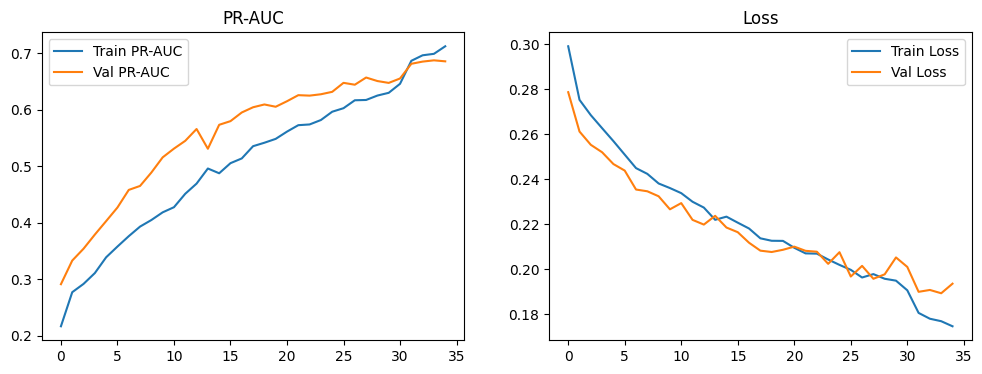

== VALIDATION RESULTS ==
Epochs: 35 (restore_best_weights)
PR-AUC:  0.6876
ROC-AUC: 0.9018


In [ ]:
def build_multi_scale_cnn_attention(input_shape, filters=32, dense_units=64,
                                    spatial_drop=0.2, dense_drop=0.5, l2_reg=None, lr=1e-3,
                                    downsample7=False, return_attention=False):
    inputs = Input(shape=input_shape)
    x_in = inputs

    if not downsample7:
        kernel_sizes = [7, 31, 91, 365]
    else:
        kernel_sizes = [1, 4, 13, 52]
        x_in = AveragePooling1D(pool_size=7)(x_in)

    reg = l2(l2_reg) if l2_reg else None

    branches = []
    for k in kernel_sizes:
        b = Conv1D(filters, k, padding='same', kernel_regularizer=reg)(x_in)
        b = BatchNormalization()(b)
        b = ReLU()(b)
        b = SpatialDropout1D(spatial_drop)(b)
        branches.append(b)

    x = Concatenate()(branches)

    # Doble de filtros pensando en futuras ejecuciones
    # (simplemente mantiene las proporciones de la red original)
    x = Conv1D(filters * 2, 3, padding='same', kernel_regularizer=reg)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Pooling
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    # Y attention adicional
    score = Dense(1, activation='tanh')(x)
    attention_weights = Softmax(axis=1, name="attention_weights")(score)
    context = Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1))([x, attention_weights])

    # Nueva combinación
    combined = Concatenate()([avg_pool, max_pool, context])

    # Y clasificador final
    x = Dense(dense_units, activation='relu', kernel_regularizer=reg)(combined)
    x = Dropout(dense_drop)(x)
    outputs = Dense(1, activation='sigmoid', name="output")(x)

    if return_attention:
        model = Model(inputs=inputs, outputs=[outputs, attention_weights])
    else:
        model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    return model

run_experiment("Attention + Pooling", X_train_dl, y_train, X_val_dl, y_val,
                model_fn=build_multi_scale_cnn_attention,
                downsample7=False, epochs=35, l2_reg=1e-4)

Registrando un rendimiento igual o ligeramente superior al modelo base, se establece como la arquitectura definitiva a hiperparametrizar.

Ante la incapacidad computacional de optimizar los hiperparámetros mediante `optuna`, se prueban algunas combinaciones utilizando la partición de validación. Para limitar los *outputs* de tantas celdas se registran los resultados en la siguiente tabla.



| Parámetro | Prueba 1 | Prueba 2 | Prueba 3 | Prueba 4 | Prueba 5 | Inicial |
|---|---|---|---|---|---|---|
| Filters | 32 | 16 | 64 | 64 | 64 | 32 |
| Dense units | 64 | 32 | 128 | 128 | 128 | 64 |
| Spatial Drop | 0.2 | 0.2 | 0.3 | 0.2 | 0.2 | 0.2 |
| Dense Drop | 0.4 | 0.5 | 0.6 | 0.5 | 0.5 | 0.5 |
| L2 | 1e-3 | 1e-5 | 1e-4 | 1e-4 | 1e-3 | 1e-4 |
| Epochs | 35 | 35 | 35 | 35 | 45 | 35 | 35 |
| Downsample | False | False | False | False | True | False |
| Fraud weight | 1 | 1 | (neg / pos) * 0.8 | 1 | 1 | 1 |
| Learning rate | 1e-4 | 1e-3 | 1e-3 | 1e-3 | 1e-3 | 1e-3 |
| **PR-AUC** | **0.631** | **0.651** | **0.666** | **0.6785** | **0.626** | **0.684** |
| **ROC-AUC** | **0.893** | **0.895** | **0.899** | **0.9015** | **0.884** | **0.9007** |

> *Nota: los resultados varían en distintas sesiones. Se han probado sin éxito varias estrategias determinsitas (incluida la sugerida por [TensorFlow](https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism)).*

In [ ]:
best_params = {
    'filters': 32,
    'dense_units': 64,
    'spatial_drop': 0.2,
    'dense_drop': 0.5,
    'l2_reg': 1e-4,
    'downsample7': False,
    'lr': 1e-3,
    'cw_pos': 1.0
}

# 3. Evaluación

Para una evaluación más robusta se aplica una validación cruzada con submuestreo aleatorio. Esta estrategia es especialmente conveniente puesto que los conjuntos de validación y test pueden contener un porcentaje elevado de muestras poco representativas (fraudes únicos).

Training seed: 42 ...
 * Test PR-AUC: 0.6811 | Test MCC: 0.6026 | Best epoch: 55 (val PR-AUC=0.6979)


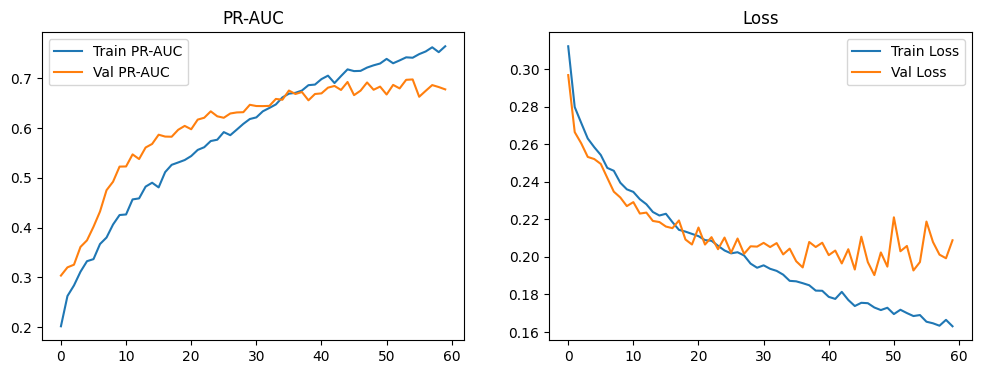

Training seed: 123 ...
 * Test PR-AUC: 0.6886 | Test MCC: 0.5856 | Best epoch: 56 (val PR-AUC=0.7057)
Training seed: 456 ...
 * Test PR-AUC: 0.6747 | Test MCC: 0.5942 | Best epoch: 56 (val PR-AUC=0.6818)
Training seed: 789 ...
 * Test PR-AUC: 0.6711 | Test MCC: 0.5808 | Best epoch: 60 (val PR-AUC=0.7018)
Training seed: 1011 ...
 * Test PR-AUC: 0.7061 | Test MCC: 0.6109 | Best epoch: 60 (val PR-AUC=0.6937)

 -> Average training time (60 epochs): 6.58 min


In [ ]:
def evaluate_final_model(df, best_params, main_seed, seeds=[SEED, 123, 456, 789, 1011]):
    results = []
    training_times = []
    # Para no reentrenar, se alamcenará el .fit del modelo con SEED del proyecto (config.py)
    main_model = None
    main_threshold = None
    main_X_te = None
    main_y_te = None

    for seed in seeds:
        print(f"Training seed: {seed} ...")
        # Para cada semilla se crean distintas particiones (escaladas sobre cada train)
        X_tr, X_v, X_te, y_tr, y_v, y_te = prepare_dl_data(df, random_seed=seed)
        # Se evita problema de memoria: "models in a loop, [...] will consume an increasing amount of memory over time"
        # https://www.tensorflow.org/api_docs/python/tf/keras/backend/clear_session
        tf.keras.backend.clear_session()

        # Modelo
        model = build_multi_scale_cnn_attention(
            input_shape=X_tr.shape[1:],
            filters=best_params['filters'],
            dense_units=best_params['dense_units'],
            spatial_drop=best_params['spatial_drop'],
            dense_drop=best_params['dense_drop'],
            l2_reg=best_params['l2_reg'],
            lr=best_params['lr'],
            downsample7=best_params['downsample7'],
            return_attention=False
        )
        cw = {0: 1.0, 1: best_params['cw_pos']}

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True
        )

        # Entreno
        start_time = time.time()
        history = model.fit(
            X_tr, y_tr, validation_data=(X_v, y_v),
            epochs=60, batch_size=128, class_weight=cw,
            verbose=0, callbacks=[early_stopping]
        )
        end_time = time.time()
        seed_train_duration = end_time - start_time
        training_times.append(seed_train_duration)
        best_epoch = int(np.argmax(history.history['val_pr_auc'])) + 1
        best_val_pr = np.max(history.history['val_pr_auc'])

        # Ajuste del threshold en val
        val_probs = model.predict(X_v, verbose=0).ravel()
        best_threshold, _, _ = utils.find_best_threshold(y_v, val_probs)

        # Predicción y métricas
        test_probs = model.predict(X_te, verbose=0).ravel()
        test_preds = (test_probs >= best_threshold).astype(int)

        run_metrics = {
            'Seed': seed,
            'Threshold': best_threshold,
            'PR-AUC': average_precision_score(y_te, test_probs),
            'ROC-AUC': roc_auc_score(y_te, test_probs),
            'MCC': matthews_corrcoef(y_te, test_preds),
            'F1_Macro': f1_score(y_te, test_preds, average='macro'),
            'Recall_Fraud': recall_score(y_te, test_preds, pos_label=1),
            'Recall_NoFraud': recall_score(y_te, test_preds, pos_label=0),
            'Precision_Fraud': precision_score(y_te, test_preds, pos_label=1, zero_division=0),
            'Precision_NoFraud': precision_score(y_te, test_preds, pos_label=0, zero_division=0)
        }
        results.append(run_metrics)
        print(
            f" * Test PR-AUC: {run_metrics['PR-AUC']:.4f} | "
            f"Test MCC: {run_metrics['MCC']:.4f} | "
            f"Best epoch: {best_epoch} (val PR-AUC={best_val_pr:.4f})"
        )

        if seed == main_seed:
           # Variables de return
            main_model = model
            main_threshold = best_threshold
            main_X_te = X_te
            main_y_te = y_te
            # Y plot
            plt.figure(figsize=(12,4))
            plt.subplot(1,2,1)
            plt.plot(history.history['pr_auc'], label='Train PR-AUC')
            plt.plot(history.history['val_pr_auc'], label='Val PR-AUC')
            plt.title('PR-AUC')
            plt.legend()
            plt.subplot(1,2,2)
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Val Loss')
            plt.title('Loss')
            plt.legend()
            plt.show()

    avg_time_sec = np.mean(training_times)
    print(f"\n{'='*50}")
    print(f" -> Average training time (60 epochs): {avg_time_sec/60:.2f} min")
    print(f"{'='*50}")

    df_results = pd.DataFrame(results)
    summary = df_results.drop('Seed', axis=1).agg(['mean', 'std']).T
    summary['Mean_Std'] = summary.apply(lambda row: f"{row['mean']:.3f} ± {row['std']:.3f}", axis=1)

    return df_results, summary, main_model, main_threshold, main_X_te, main_y_te

df_runs, df_sum, final_model, final_thresh, X_te_final, y_te_final = evaluate_final_model(
    df, best_params, main_seed=SEED, seeds=[SEED, 123, 456, 789, 1011]
)

In [ ]:
import json
# Se guarda el modelo que usa la misma partición que ML tabular (SEED=42)
model_filename = 'dl_model.keras'
final_model.save(model_filename)
# Y sus metadatos
metadata = {
    'main_seed': SEED,
    'best_threshold': final_thresh
}
meta_filename = 'dl_model_metadata.json'
with open(meta_filename, 'w') as f:
    json.dump(metadata, f)

In [ ]:
display(df_runs)
display(df_sum[['Mean_Std']])

,Seed,Threshold,PR-AUC,ROC-AUC,MCC,F1_Macro,Recall_Fraud,Recall_NoFraud,Precision_Fraud,Precision_NoFraud
0,42,0.396061,0.681072,0.900777,0.602582,0.790770,0.495256,0.987976,0.798165,0.953243
1,123,0.425758,0.688599,0.916495,0.585634,0.784411,0.495256,0.985061,0.760933,0.953111
2,456,0.336667,0.674695,0.907850,0.594151,0.787049,0.491461,0.987065,0.784848,0.952867
3,789,0.554444,0.671117,0.895736,0.580760,0.775916,0.455408,0.989616,0.808081,0.949816
4,1011,0.257475,0.706146,0.913557,0.610877,0.804787,0.607211,0.972673,0.680851,0.962676


,Mean_Std
Threshold,0.394 ± 0.110
PR-AUC,0.684 ± 0.014
ROC-AUC,0.907 ± 0.009
MCC,0.595 ± 0.012
F1_Macro,0.789 ± 0.011
Recall_Fraud,0.509 ± 0.057
Recall_NoFraud,0.984 ± 0.007
Precision_Fraud,0.767 ± 0.051
Precision_NoFraud,0.954 ± 0.005


Entre todas las particiones se obtienen métricas de separabilidad muy estables, aunque el valor del umbral sí varía bastante más y con él las distancias *precision-recall*. En cualquier caso, los resultados mejoran por mucha diferencia a cualquier modelo tabular. Con un *MCC* muy estable de 0.6 y máximos de 0.61 en *recall* y 0.81 en precisión (aunque aquí cae el *recall* a 0.45).

Para una comparativa equitativa frente a la estrategia tabular, se continúa analizando la partición con *seed* = 42.

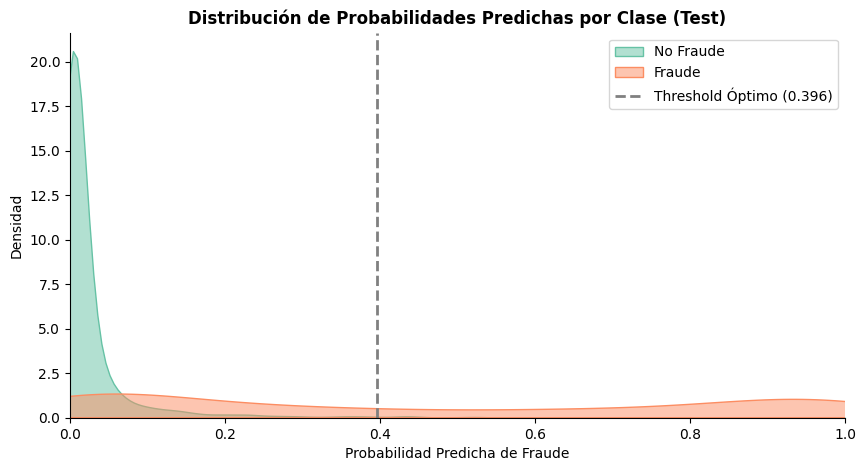

In [ ]:
def plot_probability_distribution(model, X_test, y_test, threshold):
    probs = model.predict(X_test, verbose=0).ravel()
    probs_normal = probs[y_test == 0]
    probs_fraud = probs[y_test == 1]

    plt.figure(figsize=(10, 5))
    palette = sns.color_palette("Set2")
    sns.kdeplot(probs_normal, fill=True, color=palette[0], label="No Fraude", alpha=0.5)
    sns.kdeplot(probs_fraud, fill=True, color=palette[1], label="Fraude", alpha=0.5)
    plt.axvline(threshold, color='grey', linestyle='--', linewidth=2,
                label=f'Threshold Óptimo ({threshold:.3f})')
    plt.title("Distribución de Probabilidades Predichas por Clase (Test)", fontweight='bold')
    plt.xlabel("Probabilidad Predicha de Fraude")
    plt.ylabel("Densidad")
    plt.xlim(0, 1)
    plt.legend()
    sns.despine()
    plt.show()

plot_probability_distribution(final_model, X_te_final, y_te_final, final_thresh)

El gráfico muestra una zona muy concentrada de casos legítimos cerca del 0, por lo que el modelo asigna correctamente probabilidades bajas cuando no hay fraude. En la zona de solapamiento ([0, ≈0.15)), se identifican los casos más ambiguos, donde surgen más FN y FP. En tales casos, la modificación del umbral escalaría estos errores de forma desproporcionada. Como era de esperar, la probabilidad de un cliente siendo innecesariamente molestado (FP), se reduce mucho conforme aumenta el umbral. Para mayor detalle, se grafica la curva *precision-recall*.

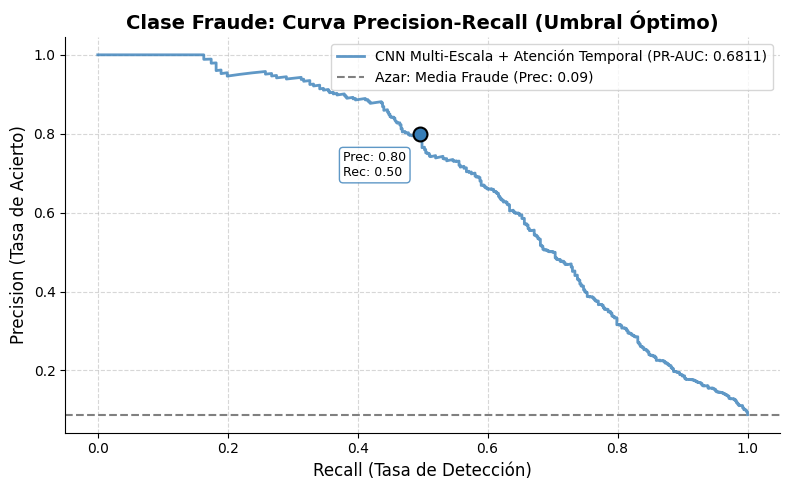

In [ ]:
def plot_pr_curve(model, X_test, y_test, threshold, model_name='CNN Multi-Escala + Atención Temporal'):
    probs = model.predict(X_test, verbose=0).ravel()
    precision, recall, pr_thresholds = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    plt.figure(figsize=(8, 5))
    color = sns.color_palette("Set1")[1]

    plt.plot(recall, precision, label=f'{model_name} (PR-AUC: {ap:.4f})',
             color=color, linewidth=2, alpha=0.8)

    # Resultados con el threshold por validation
    idx = np.argmin(np.abs(pr_thresholds - threshold))
    plt.plot(recall[idx], precision[idx], marker='o', markersize=10,
             markeredgecolor='black', markeredgewidth=1.5, color=color)
    plt.annotate(f"Prec: {precision[idx]:.2f}\nRec: {recall[idx]:.2f}",
                 (recall[idx], precision[idx]), textcoords="offset points",
                 xytext=(-55, -30), ha='left', fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

    # Línea base aleatoria
    baseline = y_test.mean()
    plt.axhline(baseline, color='gray', linestyle='--',
                label=f'Azar: Media Fraude (Prec: {baseline:.2f})')

    plt.title('Clase Fraude: Curva Precision-Recall (Umbral Óptimo)', fontsize=14, fontweight='bold')
    plt.xlabel('Recall (Tasa de Detección)', fontsize=12)
    plt.ylabel('Precision (Tasa de Acierto)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_pr_curve(final_model, X_te_final, y_te_final, final_thresh)

Leyendo el gráfico de derecha a izquierda, la curva muestra un crecimiento estable que pasa por 80% de detección con un 30% de acierto, cambiando de tendencia sobre el *recall = 0.4* y *precision = 0.9*. Mostrando una mejora drástica en el balance de costes de aumentar la precisión en comparativa con el enfoque tabular.

# 4. Explicablidad

Para interpretar el modelo, se propone graficar 3 instancias: TP, FN y TN. Para ello, se utilizan los `attention_weights` de la capa de atención temporal. Esta revela parcialmente en qué *timesteps* se fijó (pesó más) el modelo para emitir la predicción.  

In [ ]:
# Fechas
date_cols = df.columns[:-1]
dates = pd.to_datetime(date_cols, errors='coerce')

# Extracción de attention_weights
attention_layer = final_model.get_layer("attention_weights").output
explainer_model = tf.keras.Model(inputs=final_model.input, outputs=[final_model.output, attention_layer])

# Predicción y pesos del test
test_probs, test_attention = explainer_model.predict(X_te_final, verbose=0)
test_probs = test_probs.ravel()
test_attention = test_attention.squeeze()
test_preds = (test_probs >= final_thresh).astype(int)

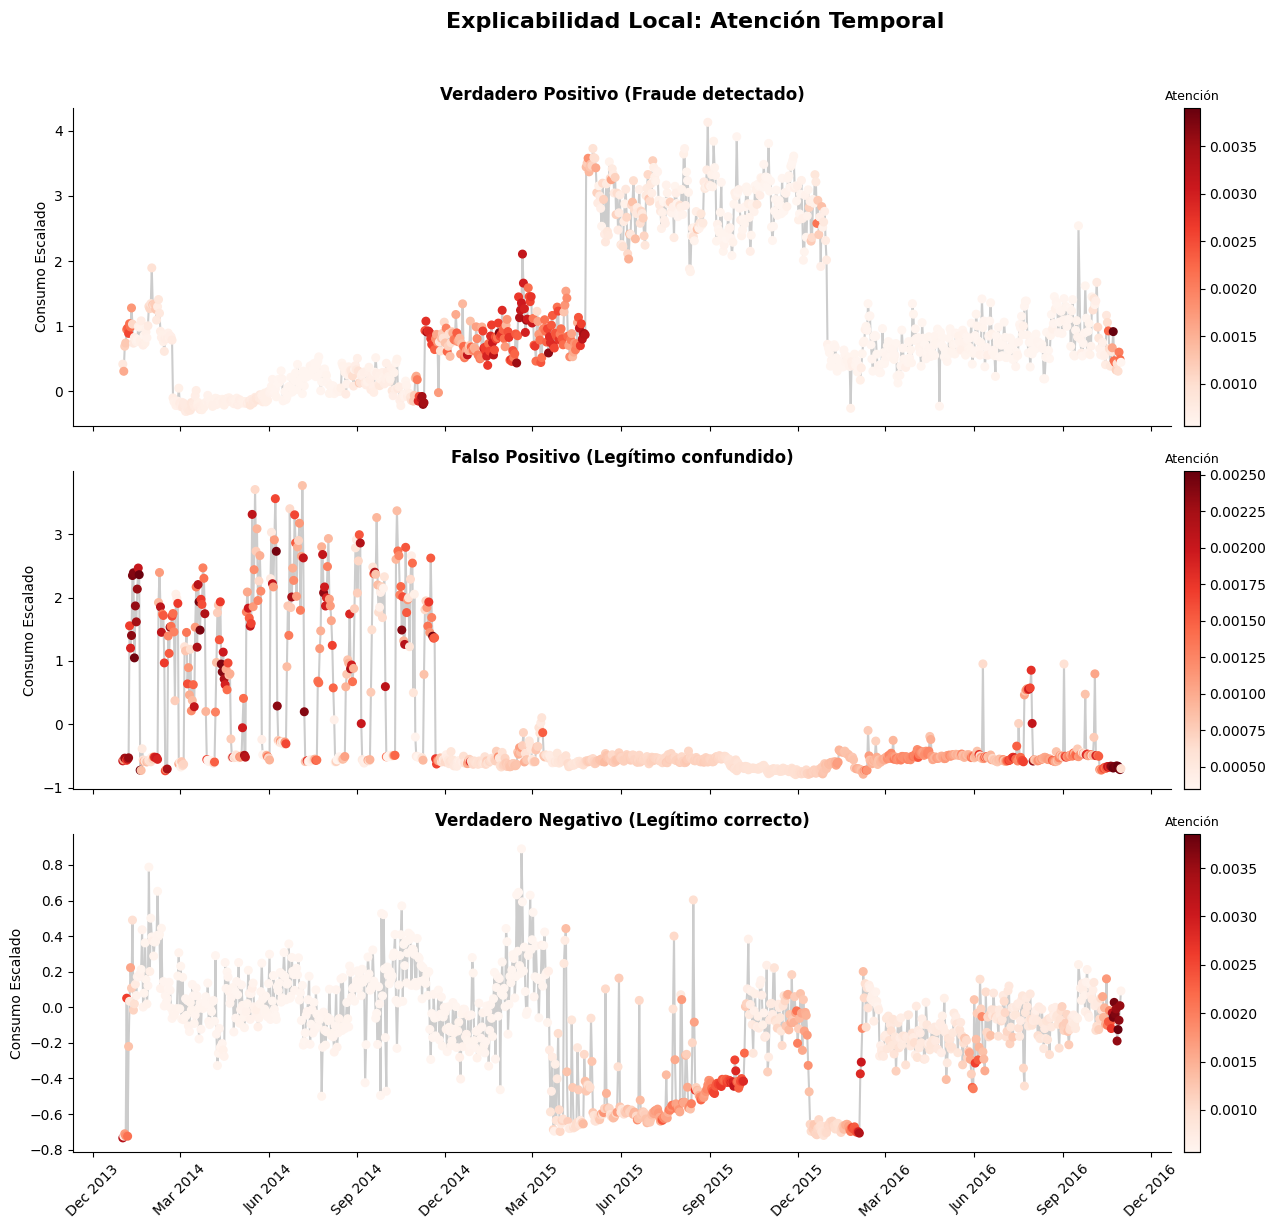

In [ ]:
def plot_local_attention(X_data, y_true, preds, attention, dates):
    # Casos
    tp_idx = np.where((y_true == 1) & (preds == 1))[0]
    fp_idx = np.where((y_true == 0) & (preds == 1))[0]
    tn_idx = np.where((y_true == 0) & (preds == 0))[0]
    # Índices de clientes a ver
    selected_indices = {
        'Verdadero Positivo (Fraude detectado)': tp_idx[42],
        'Falso Positivo (Legítimo confundido)': fp_idx[0],
        'Verdadero Negativo (Legítimo correcto)': tn_idx[42]
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle("Explicabilidad Local: Atención Temporal", fontsize=16, fontweight='bold', y=1.02)

    for ax, (title, idx) in zip(axes, selected_indices.items()):
        # Consumo escalado
        consumo = X_data[idx, :, 0]
        att_weights = attention[idx, :]
        # Línea base del consumo
        ax.plot(dates, consumo, color='gray', alpha=0.4, linewidth=1.5)
        # Puntos de attention
        sc = ax.scatter(dates, consumo, c=att_weights, cmap='Reds', s=30, zorder=3)

        ax.set_title(title, fontweight='semibold')
        ax.set_ylabel("Consumo Escalado")
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        cbar = plt.colorbar(sc, ax=ax, pad=0.01)
        cbar.ax.set_title('Atención', fontsize=9, pad=6)

    plt.xticks(rotation=45)
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_local_attention(X_te_final, y_te_final, test_preds, test_attention, dates)

**Verdadero positivo (fraude)**\
El mecanismo de atención ignora sorprendentemente el mayor pico de la serie (mediados de 2015), atribuyéndolo probablemente a un cambio de régimen legítimo. En su lugar, el foco principal se sitúa justo en el punto de inflexión de finales de 2014, donde la serie pasa de ser plana —aunque con estacionalidad— a tener un incremento errático y volátil. El modelo demuestra priorizar la inestabilidad y los cambios estructurales bruscos de varias semanas o meses por encima del volumen de consumo absoluto o picos aislados.

**Falso Positivo (no fraude)**\
La predicción errónea se fundamenta en la extrema volatilidad inicial del año 2014, donde la atención se concentra no solo en picos y valles, sino en toda la ventana temporal inestable. Seguidamente, los valores de atención son mínimos al registrar un consumo muy estable durante un periodo prolongado (año y medio). Tras este, destacan focos de atención cuando el consumo alcanza máximos locales (verano del 2016) y mínimos históricos al final de la serie. El clasificador penaliza este patrón: un periodo inicial de alta frecuencia seguido, tiempo después, de caídas abruptas, señalándolo como manipulación intermitente.

**Verdadero Negativo (no fraude)**\
Ante una serie con estacionalidad clara y sin inestabilidad extrema, los pesos de atención se reparten de forma menos agresiva. La red subraya los cambios de tendencia. Por ejemplo, el inicio de la racha alcista a mediados de 2015 y, con mayor intensidad, el mínimo local y cambio de tendencia en el primer trimestre de 2016. El modelo localiza correctamente los puntos de inflexión del consumo pero, al no encontrar la volatilidad, pondera la serie como un comportamiento legítimo.


Para estudiar la interpretabilidad con un enfoque global se presenta el siguiente gráfico.

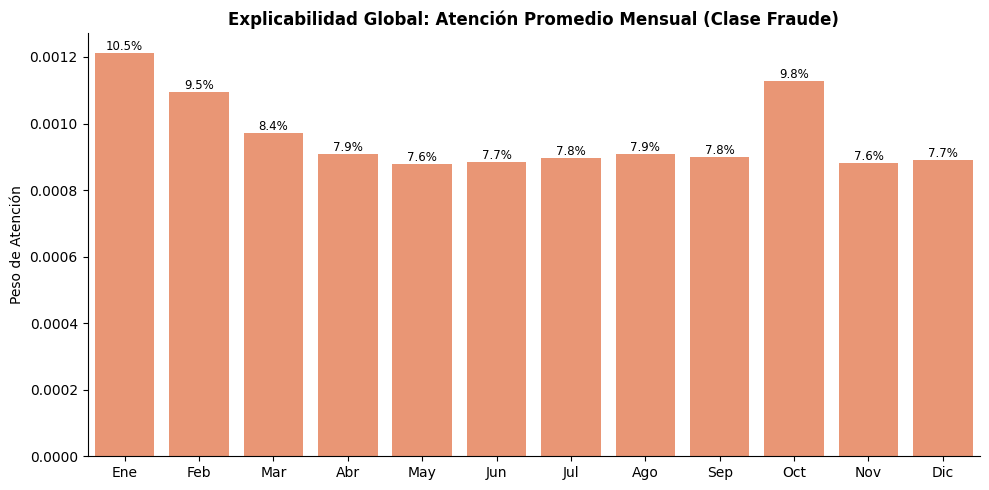

In [ ]:
def global_attention_by_month(y_true, attention, dates):
    # Promedio diario de fraude
    fraud_idx = np.where(y_true == 1)[0]
    fraud_attention = attention[fraud_idx, :]
    mean_daily_attention = np.mean(fraud_attention, axis=0)

    df_att = pd.DataFrame({
        'Date': dates,
        'Attention': mean_daily_attention
    })

    meses_es = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

    df_att['Month_Num'] = df_att['Date'].dt.month
    df_att['Month_Name'] = df_att['Month_Num'].map(meses_es)

    # Cáluclo mensual con pct
    monthly_att = df_att.groupby('Month_Num')['Attention'].mean().reset_index()
    monthly_att['Month_Name'] = monthly_att['Month_Num'].map(meses_es)
    monthly_att['Pct'] = monthly_att['Attention'] / monthly_att['Attention'].sum() * 100

    # Plot
    plt.figure(figsize=(10, 5))
    palette = sns.color_palette("Set2")
    ax = sns.barplot(data=monthly_att, x='Month_Name', y='Attention', color=palette[1])
    for bar, pct in zip(ax.patches, monthly_att['Pct']):
      ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height(),
          f'{pct:.1f}%',
          ha='center', va='bottom', fontsize=8.5
      )
    plt.xlabel(None)
    plt.title("Explicabilidad Global: Atención Promedio Mensual (Clase Fraude)", fontweight='semibold')
    plt.ylabel("Peso de Atención")
    sns.despine()
    plt.tight_layout()
    plt.show()

global_attention_by_month(y_te_final, test_attention, dates)

Viendo que la distribución de la atención temporal es uniforme, con transiciones suaves entre 7.5% y 10.5%, con un ligero despunte a principios de año. Esto revela que, a diferencia del consumo general que posee una fuerte estacionalidad, el modelo no asocia el fraude a una época concreta del calendario. La red ha aprendido que la firma del fraude es conductual, y detecta estas anomalías independientemente de la estación del año en la que ocurran.

Por otra parte, cabe destacar que los pesos de atención sí explican de forma fidedigna el contexto temporal (*x = (T, 64)*). No obstante, al emplear una arquitectura de *pooling* mixto (`GlobalMaxPooling1D` y `GlobalAveragePooling1D`) en paralelo, la predicción final es una sinergia de los tres componentes. Por lo que la atención es una técnica explicativa parcial.

Para complementar la interpretabilidad de forma independiente a la arquitectura, se propone la técnica de sensibilidad por oclusión. Este método cambia periodos de consumo real por un *baseline* midiendo cómo cambia la probabilidad de fraude.

> *Nota: para no crear fraudes artificiales, el canal que usa la máscara de nulos no se modifica. La aplicación del método solo valora el consumo.*

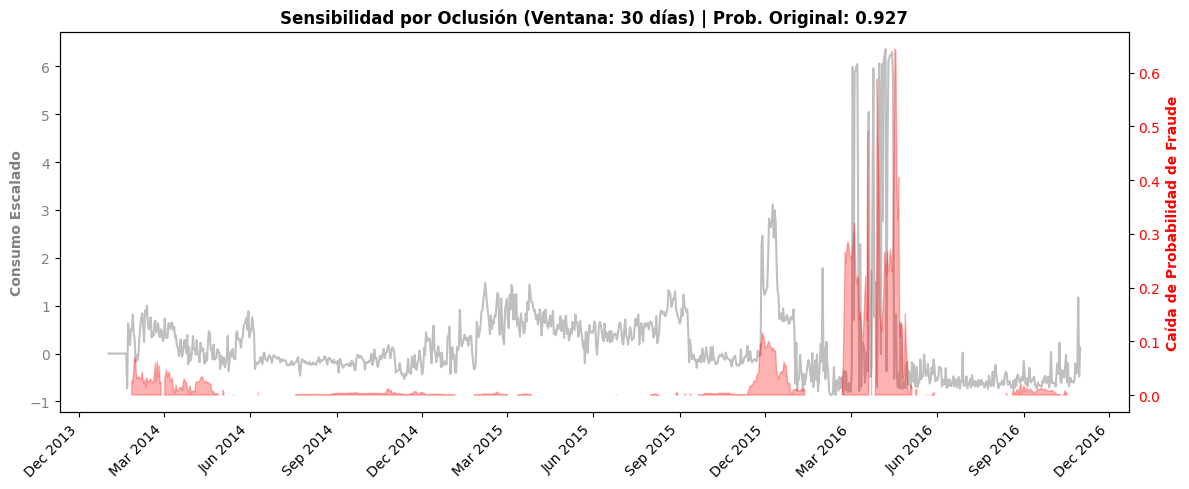

In [ ]:
def compute_occlusion(model, x_instance, window_size=30):
    timesteps = x_instance.shape[0]
    # Probabilidad original
    original_prob = model.predict(x_instance[np.newaxis, ...], verbose=0)[0, 0]
    batch_x = []
    centers = []
    for i in range(timesteps - window_size + 1):
        x_occ = x_instance.copy()
        # Se ocluye el consumo (canal 0). Al estar estandarizado, 0 es la media
        x_occ[i:i+window_size, 0] = 0.0
        batch_x.append(x_occ)
        centers.append(i + window_size // 2)
    batch_x = np.array(batch_x)
    # Predicción
    new_probs = model.predict(batch_x, verbose=0).ravel()
    # ¿Cuánto cae la probabilidad en cada tramo?
    drops = np.zeros(timesteps)
    for center, new_prob in zip(centers, new_probs):
        drops[center] = original_prob - new_prob

    return original_prob, drops

def plot_occlusion(model, X_data, y_true, preds, dates, i_tp_idx, window_size=30):
    # Idx de TP (fraude)
    tp_idx = np.where((y_true == 1) & (preds == 1))[0]
    idx = tp_idx[i_tp_idx]
    x_instance = X_data[idx]
    # Cálculo oclusión
    orig_prob, drops = compute_occlusion(model, x_instance, window_size)
    consumo = x_instance[:, 0]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 5))
    # Consumo real
    ax1.plot(dates, consumo, color='gray', alpha=0.5, label='Consumo Escalado')
    ax1.set_ylabel('Consumo Escalado', color='gray', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='gray')
    # Caída de Probabilidad
    ax2 = ax1.twinx()
    # Rojo cuando caen
    ax2.fill_between(dates, 0, drops, where=(drops > 0), color='red', alpha=0.3, label='Importancia (Caída de Probabilidad)')
    ax2.set_ylabel('Caída de Probabilidad de Fraude', color='red', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='red')
    plt.title(f'Sensibilidad por Oclusión (Ventana: {window_size} días) | Prob. Original: {orig_prob:.3f}', fontweight='bold')
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()

plot_occlusion(final_model, X_te_final, y_te_final, test_preds, dates, i_tp_idx=1, window_size=30)

Al ocluir periodos prolongados (un mes), se observa que la confianza del clasificador se desploma, con una caída de probabilidad superior a 0.6. Esto sucede concretamente al ocultar la zona de mayor inestabilidad y consumos más extremos de toda la serie (primer semestre de 2016). Lo que identifica este patrón como evidencia clave para el modelo. En contraste, ocultar el episodio anómalo de finales de 2015 produce una caída moderada (≈0.1), insuficiente para cambiar la clasificación. Concluyendo que el modelo fundamenta su decisión principalmente en patrones prolongados de alta magnitud y varianza sostenida.

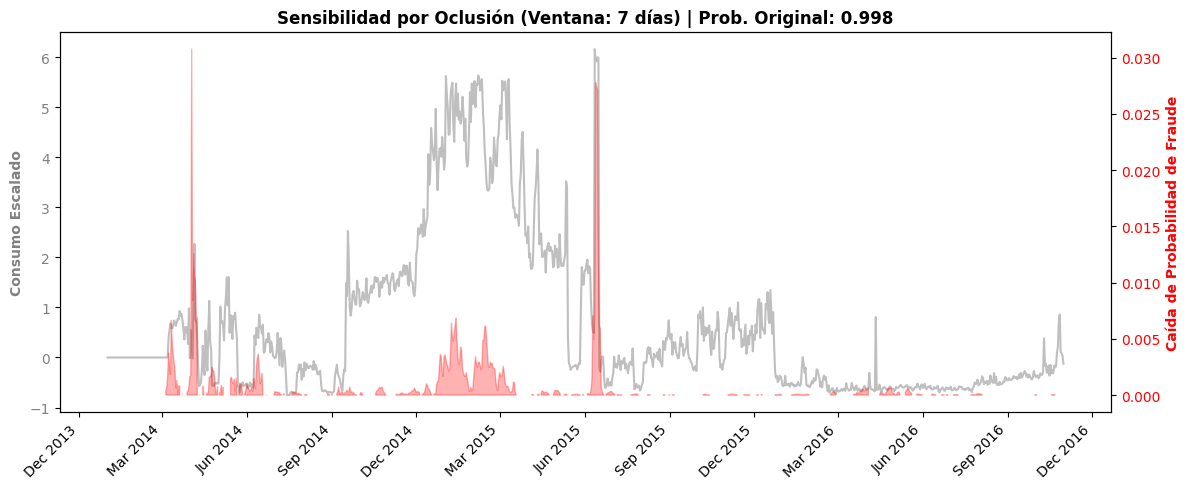

In [ ]:
plot_occlusion(final_model, X_te_final, y_te_final, test_preds, dates, i_tp_idx=-42, window_size=7)

Con una ventana de una semana, la caída máxima de probabilidad apenas roza el 0.03. El modelo penaliza principalmente los eventos extremos puntuales —los picos de consumo de inicios de 2014 y mediados de 2015— aunque su impacto en la decisión final es mínimo. Esto evidencia la robustez del modelo: la combinación de *global pooling* y atención exige evidencia contextual extensa para clasificar una serie como fraudulenta, y no yerra por periodos anómalos y puntuales de corta duración que pueden ser comunes a todos los clientes.